In [ ]:
# Performing tests for a particular model 

In [1]:
from collections import OrderedDict
import re
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from tqdm.notebook import tqdm
from tasks import PolynomialRegression, ChebyshevPolynomialRegression
import numpy as np
from eval import get_run_metrics, read_run_dir, get_model_from_run
from plot_utils import basic_plot, collect_results, relevant_model_names
from samplers import get_data_sampler
from tasks import get_task_sampler
import datetime


In [2]:
directory = "/.../in-context-learning/" #Put your own directory
run_dir = directory + "models/"

device = torch.device("cpu")
print("device : ", device)

device :  cpu


In [3]:
n_layer = 6 # You can choose in {1,2,3,6,9,12} according to your models
n_ah = 4 # You can choose in {1,2,3,8}
n_deg= 1
model = "tiny" # "toy" : for models with layers <= 3, "tiny" for 6l and "standard" for l = 12
n_embed = 64 # 64 for all models except standard 256
task = "polynomial_regression"

run_id = f"1d_{model}{n_embed}_{n_layer}l_{n_ah}ah_deg_{n_deg}"
#run_id = f"1dbu_{model}{n_embed}_{n_layer}l_{n_ah}ah_deg_{n_deg}1" # For uniforme
#run_id = f"1dbg_{model}{n_embed}_{n_layer}l_{n_ah}ah_deg_{n_deg}1" # For bimodale
print(run_id)

1d_tiny64_6l_4ah_deg_1


In [4]:
run_path = os.path.join(run_dir, task, run_id)
#print("run_path : ", run_path)
model, conf = get_model_from_run(run_path,device=device) #Ici, on a model et conf
n_dims = conf.model.n_dims
#print("n_dims", n_dims)
batch_size = conf.training.batch_size
#print("batch size", batch_size)

In [5]:
data_sampler = get_data_sampler(conf.training.data, n_dims) 
task_sampler = get_task_sampler(
    "toy_polynomial_regression",
    n_dims,
    batch_size,
    **conf.training.task_kwargs
)
task = task_sampler(max_dim=1)

xs = data_sampler.sample_xs(b_size=batch_size, n_points=conf.training.curriculum.points.end-1) #torch.Size([64, 40, 1])

In [6]:
# You can uncomment and fix the size of the size of prompts you want to ICL
#xs = data_sampler.sample_xs(b_size=batch_size, n_points=100)

In [7]:
#Run Here if you want to do the test on a xs in other distribution such as N(0,1) ou U(-1,1)
for i in range(xs.shape[0]):      
    for j in range(xs.shape[1]):    
        for k in range(xs.shape[2]):  
            torch.manual_seed(100*i + 10*j +k)
            #xs[i, j, k] = -1 + torch.rand(1) * 2 # Random value in U(-1,1)
            xs[i, j, k] = torch.randn(1)  # Random value in N(0,1)

In [8]:
#Uncomment if you want to sort sample data
#xs_sorted, _ = torch.sort(xs, dim=1)
#xs = xs_sorted

In [9]:
# If you want to evaluate on an other function you can change it in : task.py line 604/605 and put the coefficients you want
ys = task.evaluate(xs) #torch.Size([64, 40])
with torch.no_grad():
    pred = model(xs,ys)

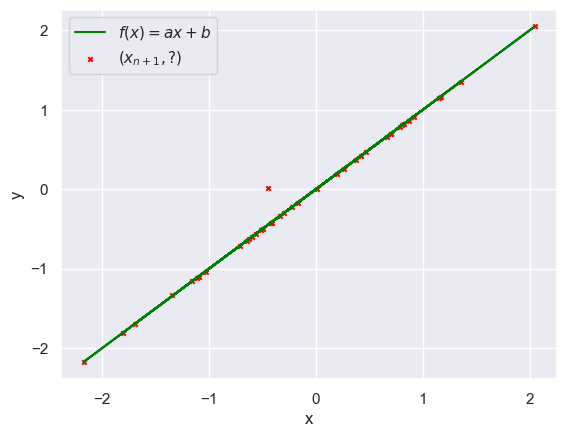

In [10]:
#If you want to plot a specific batch
batch2plot = 2 # on a y = f(x) dans chaque batch, donc on choisit un a plot
xs_np = xs[batch2plot,:,0].numpy()
ys_np = ys[batch2plot,:].numpy()
pred_np = pred[batch2plot,:].numpy()
plt.plot(xs_np, ys_np, label="$f(x)=ax+b$", color='green')
plt.scatter(xs_np, pred_np, label="$(x_{n+1}, ?)$",color='red',marker="x",s=10)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

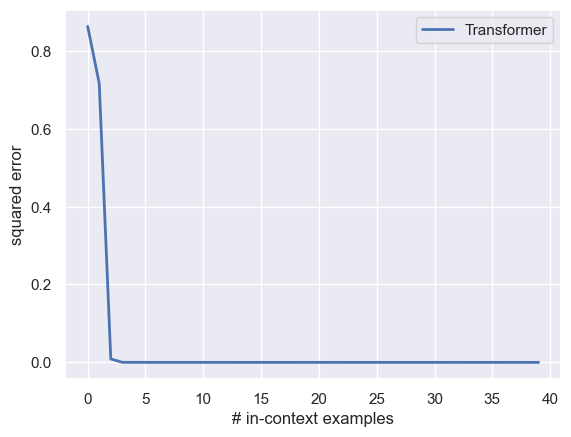

In [11]:
metric = task.get_metric()
loss = metric(pred, ys).numpy()  
plt.figure()
plt.plot(loss.mean(axis=0), lw=2, label="Transformer")
plt.xlabel("# in-context examples")
plt.ylabel("squared error")
plt.legend()
plt.show()  

scores [0.0002275043516419828, 0.0058739883825182915, 0.560213565826416, 1.9414523839950562, 5.027405261993408, 12.846177101135254, 17.819868087768555, 37.53133773803711, 63.5073356628418, 91.73003387451172]
scores vir [0.0, 0.01, 0.56, 1.94, 5.03, 12.85, 17.82, 37.53, 63.51, 91.73]
sigmas [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


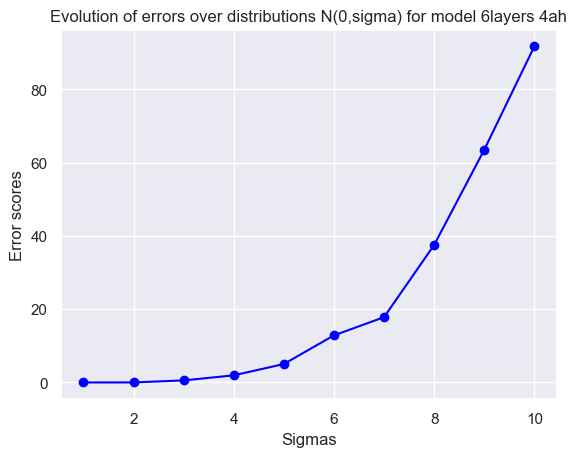

In [12]:
##### Run if you want to calculate the epsilon error on N=100 linear functions of type ax+b with a,b in N(0,1) it may take some time for running
scores = []
sigmas = []
for sigma in range(1, 11):
    mean_scores = 0
    torch.manual_seed(sigma)
    values = torch.randn(200)*sigma
    coeff_a = values[:100]
    coeff_b = values[100:]

    for i in range(len(coeff_a)):
        z = coeff_a[i] * xs + coeff_b[i] # torch.Size([64, 40, 1])
        z = z[:,:,0] # torch.Size([64, 40])
        
        #z = z[:,1:,0]
        
        with torch.no_grad():
            p = model(xs,z)
        #print(z.shape)
        #print("z", z)
        #print("p", p)
        #p = 0*p
        diff = z[:,2:] - p[:,2:]
        
        #print("dif", diff)
        #mi = torch.norm(diff, p=2, dim=1) # Norm 2
        #print("oldmi", mi)
        #mi = torch.mean(mi)
        mi = diff.square().mean()
        #print("mi", mi)
        #mi = torch.norm(z-p, p=2)
        mean_scores = mean_scores + (1/len(coeff_a))* mi
    
    scores.append(mean_scores)
    sigmas.append(sigma)
        

scores_np = [sss.item() for sss in scores]
print("scores",scores_np)
print("scores vir", [round(score, 2) for score in scores_np])
print("sigmas",sigmas)

plt.figure()
plt.plot(sigmas, scores_np, marker='o', color='blue', label='Scores en fonction de sigmas')

# Ajouter des labels et un titre
plt.xlabel('Sigmas')
plt.ylabel('Error scores')
plt.title(f'Evolution of errors over distributions N(0,sigma) for model {n_layer}layers {n_ah}ah')    
plt.savefig(f"{directory}figures_scores/{run_id}_on_{task.max_dim}.png")

plt.show()